In [16]:
import os
import sys

# Controlla se il notebook sta girando su Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    # Monta il drive
    drive.mount('/content/drive')
    
    # IMPORTANTE: Inserisci qui il percorso esatto della cartella su Drive.
    # Se è una cartella condivisa standard di cui avete creato una scorciatoia 
    # nel vostro Drive personale, il percorso sarà simile a questo:
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
    
    # Se invece è un "Drive Condiviso" aziendale/universitario:
    # BASE_PATH = '/content/drive/Shareddrives/Nome_Drive/Nome_Progetto/'

else:
    print("Ambiente locale rilevato.")
    # Imposta la directory base in locale. 
    # './' significa la cartella in cui si trova attualmente il notebook.
    # Oppure usa '../' se i notebook sono in una sottocartella e i dati fuori.
    BASE_PATH = '../'

print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import e Configurazione

In [17]:
import zipfile
import gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight

In [23]:

# --- CONFIGURAZIONE ---

# Ora costruisci i percorsi dei file unendo il BASE_PATH al resto
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "train.csv")
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "val.csv")

IMG_SIZE = (512, 512)
BATCH_SIZE = 8
SEED = 42

# Medie e std di ImageNet
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

# Cartella per salvare i modelli
OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260611_baseline_resnet50_fine_tuned_0')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Imposta il seed per la riproducibilità
keras.utils.set_random_seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)
print(OUTPUT_DIR)

../data/processed/metadata/train.csv
../data/processed/metadata/val.csv
../experiments/exp20260611_baseline_resnet50_fine_tuned_0


#### Verifica presenza file dataset preprocessato

In [24]:
# ID del file su Google Drive
PROCESSED_DRIVE_ID = "16qdV3arYBeMK7nLZpm3dwGV4lzTLVYmo"
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

def processed_data_ready():
    if not os.path.isfile(TRAIN_CSV_PATH) or not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(first_path)
    except Exception:
        return False

if not processed_data_ready():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print(f"Dataset estratto in: {os.path.join(BASE_PATH, 'data')}")
else:
    print("Dataset già presente, salto il download.")


Dataset già presente, salto il download.


#### Preparazione Dati e Pipeline

Filtriamo il dataset per usare solo i dati reali di train e validation. Includiamo la funzione aggiornata con l'aggiunta del rumore gaussiano per la data augmentation.

In [25]:
# 1. Carica e filtra il CSV
df_train = pd.read_csv(TRAIN_CSV_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

# 2. Calcola i pesi delle classi per il training
labels_train = df_train['cancer'].values
classes = np.unique(labels_train)
weights = compute_class_weight('balanced', classes=classes, y=labels_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class Weights: {class_weight_dict}")

# 3. Funzioni tf.data (con rumore gaussiano per augmentation)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
        
    return img, tf.cast(label, tf.float32)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, -3.0, 3.0)
    return img, label
# Niente rotazioni forti, nemmeno zoom

def make_dataset(df, shuffle=False, augment_data=False):
    paths = df['processed_path'].values
    labels = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Costruisci i dataset
train_ds = make_dataset(df_train, shuffle=True, augment_data=False) # Da mettere a True se vuoi data augmentation
val_ds = make_dataset(df_val, shuffle=False, augment_data=False) 

Class Weights: {0: 0.5999412110523221, 1: 3.001470588235294}


#### Costruzione dell'Architettura ResNet-50

Creiamo la funzione che istanzia il modello. Inizialmente, congeliamo tutto il backbone (ResNet-50) per addestrare solo la nostra testina di classificazione (custom head).

In [26]:
def build_base_model():
    # Carica il backbone ResNet-50 pre-addestrato
    base_model = keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(512, 512, 3)
    )
    
    # Congela il backbone per la Fase 1
    base_model.trainable = False
    
    # Costruisci l'architettura completa
    inputs = keras.Input(shape=(512, 512, 3))
    
    # training=False è fondamentale qui per la Batch Normalization
    x = base_model(inputs, training=False) 
    
    # Global Average Pooling (scelta ottimale per ridurre i parametri)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Custom Head con LeakyReLU
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x) # alpha è la pendenza per i valori negativi
    x = layers.Dropout(0.5)(x)
    
    # Output binario (1 neurone con sigmoid)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_base_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

#### Fase 1: Addestramento Custom Head

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall')
    ]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'baseline_fase1_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

history_phase1 = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase1
)

Epoch 1/25


I0000 00:00:1781160330.605118    5290 service.cc:153] XLA service 0x79070406a120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781160330.605211    5290 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781160331.198566    5290 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781160335.236133    5290 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781160335.468266    5290 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14952__.195
I0000 00:00:1781160349.808044    5290 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


256/256 ━━━━━━━━━━━━━━━━━━━━ 80s 204ms/step - accuracy: 0.5546 - auc: 0.5470 - loss: 0.8707 - recall: 0.5294 - val_accuracy: 0.5332 - val_auc: 0.5375 - val_loss: 0.7805 - val_recall: 0.5342
Epoch 2/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 104ms/step - accuracy: 0.5478 - auc: 0.5601 - loss: 0.8062 - recall: 0.5441 - val_accuracy: 0.7414 - val_auc: 0.5981 - val_loss: 0.5917 - val_recall: 0.2740
Epoch 3/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - accuracy: 0.5698 - auc: 0.5877 - loss: 0.7641 - recall: 0.5618 - val_accuracy: 0.2860 - val_auc: 0.5871 - val_loss: 1.0170 - val_recall: 0.8904
Epoch 4/25
  2/256 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.6562 - auc: 0.7205 - loss: 0.7758 - recall: 0.6667  

W0000 00:00:1781160468.573784    6412 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554752 bytes after encountering the first element of size 33554752 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.5742 - auc: 0.5871 - loss: 0.7704 - recall: 0.5882 - val_accuracy: 0.2471 - val_auc: 0.6321 - val_loss: 1.2717 - val_recall: 0.9589
Epoch 5/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 25s 97ms/step - accuracy: 0.5757 - auc: 0.6086 - loss: 0.7394 - recall: 0.5824 - val_accuracy: 0.4302 - val_auc: 0.5535 - val_loss: 0.9595 - val_recall: 0.8082
Epoch 6/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 25s 97ms/step - accuracy: 0.5875 - auc: 0.6200 - loss: 0.7271 - recall: 0.6000 - val_accuracy: 0.3593 - val_auc: 0.6206 - val_loss: 1.0450 - val_recall: 0.8493
Epoch 7/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 26s 100ms/step - accuracy: 0.5938 - auc: 0.6367 - loss: 0.7197 - recall: 0.6147 - val_accuracy: 0.6499 - val_auc: 0.5990 - val_loss: 0.6565 - val_recall: 0.4247
Epoch 8/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.6090 - auc: 0.6639 - loss: 0.6997 - recall: 0.6588 - val_accuracy: 0.4073 - val_auc: 0.6164 - val_loss: 0.8682 - val_recall: 0.8356
Epoch 9/

...

256/256 ━━━━━━━━━━━━━━━━━━━━ 26s 99ms/step - accuracy: 0.6031 - auc: 0.6409 - loss: 0.7099 - recall: 0.6029 - val_accuracy: 0.5172 - val_auc: 0.6339 - val_loss: 0.7337 - val_recall: 0.6575
Epoch 12/25
  2/256 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.5312 - auc: 0.0000e+00 - loss: 0.4448 - recall: 0.0000e+00 

W0000 00:00:1781160692.375680    6412 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554752 bytes after encountering the first element of size 33554752 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


256/256 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.6139 - auc: 0.6504 - loss: 0.6970 - recall: 0.5882 - val_accuracy: 0.7254 - val_auc: 0.6211 - val_loss: 0.6081 - val_recall: 0.4384
Epoch 13/25
  1/256 ━━━━━━━━━━━━━━━━━━━━ 1:04 252ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.3706 - recall: 1.0000

W0000 00:00:1781160717.471794    6412 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554752 bytes after encountering the first element of size 33554752 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


256/256 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - accuracy: 0.6134 - auc: 0.6304 - loss: 0.7063 - recall: 0.5882 - val_accuracy: 0.5950 - val_auc: 0.6151 - val_loss: 0.7025 - val_recall: 0.5616
Epoch 14/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 25s 97ms/step - accuracy: 0.6129 - auc: 0.6665 - loss: 0.6897 - recall: 0.6500 - val_accuracy: 0.6270 - val_auc: 0.5946 - val_loss: 0.6873 - val_recall: 0.5205
Epoch 15/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.5938 - auc: 0.6345 - loss: 0.7050 - recall: 0.5500 - val_accuracy: 0.5286 - val_auc: 0.6003 - val_loss: 0.7850 - val_recall: 0.6164
Epoch 16/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.5914 - auc: 0.6306 - loss: 0.7142 - recall: 0.6206 - val_accuracy: 0.6384 - val_auc: 0.5912 - val_loss: 0.6490 - val_recall: 0.4795
Epoch 17/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 25s 97ms/step - accuracy: 0.6002 - auc: 0.6390 - loss: 0.7010 - recall: 0.5971 - val_accuracy: 0.8055 - val_auc: 0.5962 - val_loss: 0.5673 - val_recall: 0.1096


#### Fase 2: Fine Tuning

In [28]:
base_model.trainable = True
set_trainable = False

for layer in base_model.layers:
    if layer.name == 'conv5_block3_1_conv': # sblocca ultimo blocco residuale dell'architettura
        set_trainable = True
    layer.trainable = set_trainable

print(f"Totale layer nel base_model: {len(base_model.layers)}")
print(f"Layer addestrabili: {len(model.trainable_variables)}")

def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss_fn

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall')
    ]
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        min_delta=1e-3,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'baseline_final_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        mode='max',
        min_lr=1e-7
    )
]

history_phase2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase2
)

print(f"\nTraining completato. Il miglior modello è salvato in: {os.path.join(OUTPUT_DIR, 'baseline_final_best.keras')}")

Totale layer nel base_model: 175
Layer addestrabili: 18
Epoch 1/30


I0000 00:00:1781160856.899365    5292 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_70358__.209


256/256 ━━━━━━━━━━━━━━━━━━━━ 74s 198ms/step - accuracy: 0.6335 - auc: 0.6579 - loss: 0.1806 - recall: 0.6088 - val_accuracy: 0.7529 - val_auc: 0.5848 - val_loss: 0.1501 - val_recall: 0.2192 - learning_rate: 1.0000e-05
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 102ms/step - accuracy: 0.6830 - auc: 0.7071 - loss: 0.1547 - recall: 0.5794 - val_accuracy: 0.6911 - val_auc: 0.5732 - val_loss: 0.1528 - val_recall: 0.3425 - learning_rate: 1.0000e-05
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 30s 116ms/step - accuracy: 0.7261 - auc: 0.7214 - loss: 0.1470 - recall: 0.5588 - val_accuracy: 0.7918 - val_auc: 0.5888 - val_loss: 0.1355 - val_recall: 0.2192 - learning_rate: 1.0000e-05
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.7511 - auc: 0.7225 - loss: 0.1395 - recall: 0.5176 - val_accuracy: 0.7963 - val_auc: 0.5828 - val_loss: 0.1321 - val_recall: 0.1370 - learning_rate: 1.0000e-05
Epoch 5/30
  1/256 ━━━━━━━━━━━━━━━━━━━━ 1:01 241ms/step - accuracy: 0.8750 - auc: 0.0000e+00 - 

W0000 00:00:1781161001.724140    9489 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554752 bytes after encountering the first element of size 33554752 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.7629 - auc: 0.7499 - loss: 0.1349 - recall: 0.5176 - val_accuracy: 0.6865 - val_auc: 0.5857 - val_loss: 0.1519 - val_recall: 0.3151 - learning_rate: 1.0000e-05
Epoch 6/30
  1/256 ━━━━━━━━━━━━━━━━━━━━ 56s 220ms/step - accuracy: 0.6250 - auc: 0.0000e+00 - loss: 0.0842 - recall: 0.0000e+00

...

256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.7986 - auc: 0.7822 - loss: 0.1257 - recall: 0.5647 - val_accuracy: 0.6247 - val_auc: 0.5776 - val_loss: 0.1830 - val_recall: 0.4384 - learning_rate: 1.0000e-05
Epoch 7/30
  2/256 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.7812 - auc: 1.0000 - loss: 0.0830 - recall: 1.0000  

W0000 00:00:1781161055.711568    9489 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554752 bytes after encountering the first element of size 33554752 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.8050 - auc: 0.7999 - loss: 0.1235 - recall: 0.5647 - val_accuracy: 0.7666 - val_auc: 0.5717 - val_loss: 0.1390 - val_recall: 0.1507 - learning_rate: 5.0000e-06
Epoch 8/30
  1/256 ━━━━━━━━━━━━━━━━━━━━ 1:01 242ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 0.1326 - recall: 0.6667

W0000 00:00:1781161082.827409    9489 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554752 bytes after encountering the first element of size 33554752 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.8226 - auc: 0.8294 - loss: 0.1161 - recall: 0.5971 - val_accuracy: 0.7712 - val_auc: 0.5743 - val_loss: 0.1398 - val_recall: 0.1781 - learning_rate: 5.0000e-06

Training completato. Il miglior modello è salvato in: ../experiments/exp20260611_baseline_resnet50_fine_tuned_0/baseline_final_best.keras


Analisi Overfitting - Fase 2 (Fine Tuning):
Grafico salvato in: ../experiments/exp20260611_baseline_resnet50_fine_tuned_0/figures/training_history_fase2.png


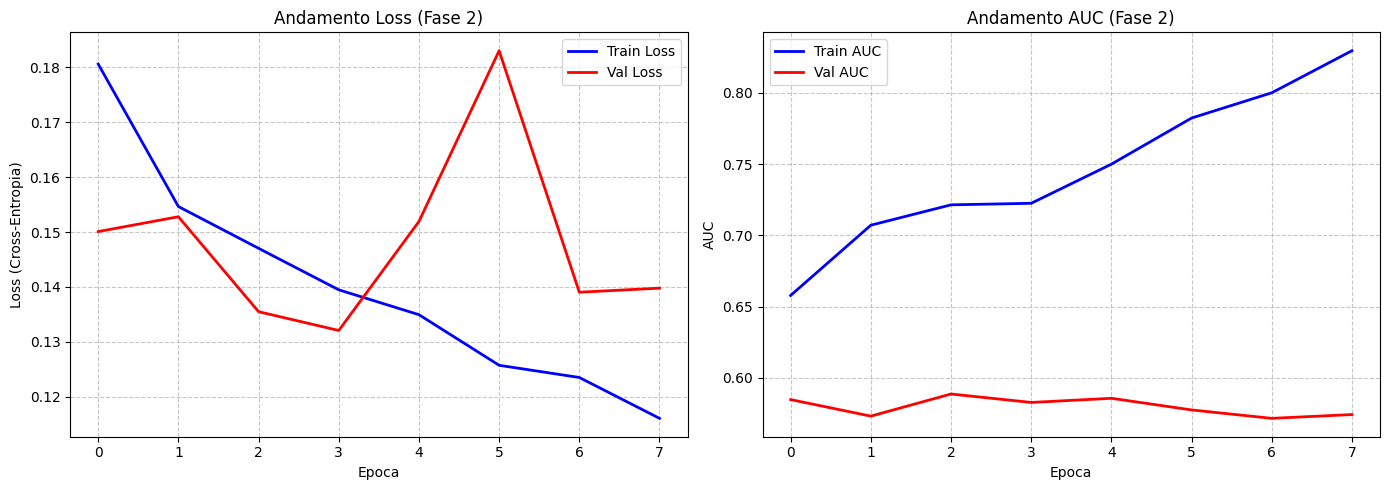

In [29]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss (Cross-Entropia)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafico salvato in: {save_path}")
    plt.show()

FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(
    history_phase2, "(Fase 2)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png')
)

#### Valutazione su Validation Set

AUC: 0.5891
Soglia ottimale: 0.406
              precision    recall  f1-score   support

   No cancro       0.87      0.60      0.71       364
      Cancro       0.21      0.55      0.31        73

    accuracy                           0.59       437
   macro avg       0.54      0.57      0.51       437
weighted avg       0.76      0.59      0.64       437

Metriche salvate in: ../experiments/exp20260611_baseline_resnet50_fine_tuned_0/val_metrics.json


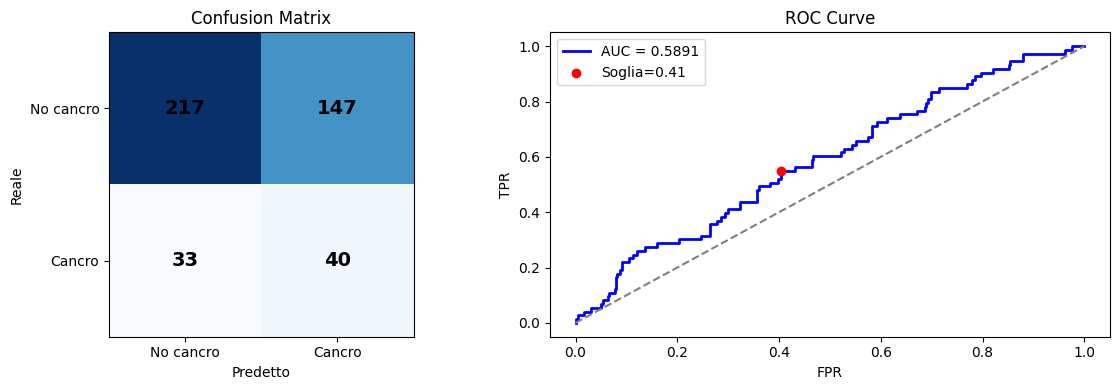

Figura salvata in: ../experiments/exp20260611_baseline_resnet50_fine_tuned_0/figures/val_confusion_roc.png


In [30]:
import json
from sklearn.metrics import (confusion_matrix, roc_curve,
                             classification_report, roc_auc_score,
                             precision_score, recall_score, f1_score)

# Carica il miglior modello salvato
best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR, 'baseline_final_best.keras'),
    custom_objects={'loss_fn': focal_loss(gamma=2.0, alpha=0.75)}
)

# Predizioni sul validation set
y_true, y_pred_prob = [], []
for imgs, labels in val_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Soglia ottimale (Youden's J)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
y_pred = (y_pred_prob >= best_threshold).astype(int)

val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])

print(f"AUC: {val_auc:.4f}")
print(f"Soglia ottimale: {best_threshold:.3f}")
print(report_str)

# Salva metriche in JSON
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    'split': 'validation',
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
metrics_path = os.path.join(OUTPUT_DIR, 'val_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print(f"Metriche salvate in: {metrics_path}")

# Figura: Confusion Matrix + ROC curve
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5, label=f'Soglia={best_threshold:.2f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'val_confusion_roc.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {fig_path}")